# Q1. How should ClinVar missense variants be split for reliable evaluation on previously unseen genes?

Prepare the **full missense cohort**, using the pilot's filters and split rules without its 5,000-variant cap. [Dependencies](../requirements.txt) · [Implementation](src/q1_full.py) · CPU only.

Use the same **5 September 2026 GRCh38 ClinVar snapshot** and pinned reference as the pilot. Q0's July snapshot is a separate input.

In [1]:
from src import q1_full
q1_full.settings()

All eligible missense SNVs · same September 2026 source and pilot filters · no sampling cap
1,024-base contexts · seed 42 · original 70/30 group assignment · CPU only
data/clinvar-train.vcf = training; data/clinvar-test.vcf = validation.


## Filter and preserve groups

Keep missense A/C/G/T substitutions on chromosomes 1–22, X and Y, with **at least two review stars**, usable gene IDs and unambiguous benign/pathogenic labels. Exclude conflicts and inconsistent duplicates; require exact `MC=SO:0001583`. [Exact filtering implementation](src/q0.py).

Keep the original **seed-42, 70/30 whole-group assignments**. Genes, loci, source IDs and overlapping 1,024-base windows connect variants across the broader eligible SNV cohort, including nonmissense bridges. Group sizes make the percentages approximate; labels do not determine assignment.

Extract every eligible reference/alternate context. Exclude truncated or non-ACGT windows; fail on a REF mismatch or cross-split identical context, including reverse complements. Preserve every pilot variant's split and DNA.

In [2]:
q1_full.run_checks()
full, sequences = q1_full.prepare()

21 split and sequence integrity tests passed.
10 additional full-dataset integrity tests passed.
Verify the pinned September inputs and original group assignments.


5,000 sampled variants retained; 6 leakage check groups passed.


Extract reference/alternate DNA for all 65,270 eligible missense variants.


Leakage checks passed; export and recheck the complete VCF records.


65,270 full-dataset variants; 0 sequence exclusions; 8 audit groups passed.


## Frozen full partitions

**Training** fits preprocessing and models. **Validation** selects settings and compares models. The test-named VCF remains validation, including previously evaluated pilot variants; there is no separate test stage.

[Training VCF](../data/clinvar-train.vcf) · [Validation VCF](../data/clinvar-test.vcf) · [Manifest](results/q1/full/split_manifest.csv) · [Protocol](results/q1/full/protocol.json) · [Sequence exclusions](results/q1/full/sequence_exclusions.csv)

Use these full inputs for new experiments. Existing Q2/Q8/Q9/Q10 results retain their original pilot inputs and identities. Clinical annotations supply eligibility and outcomes; predictor inputs contain only DNA.

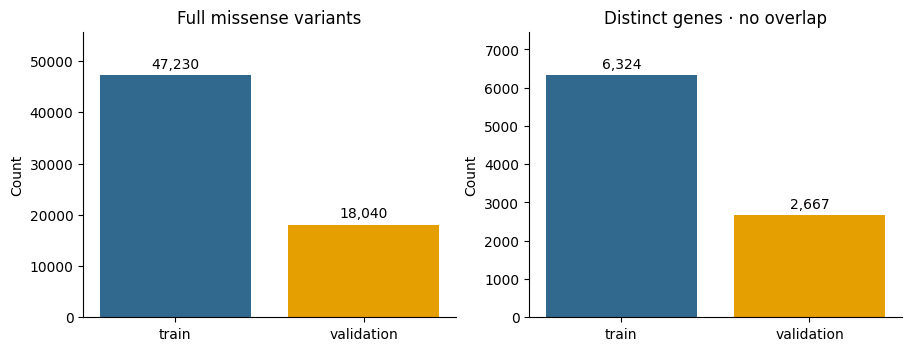

,variants,components,B,P,genes,percent,vcf
split,,,,,,,
train,47230,4894,28866,18364,6324,72.36,clinvar-train.vcf
validation,18040,2032,11450,6590,2667,27.64,clinvar-test.vcf


,stage,retained,removed
0,All records,4469028,0
1,No inconsistent duplicate annotations,4469028,0
2,"Chromosomes 1–22, X, Y",4465847,3181
3,Single A/C/G/T substitution,4157786,308061
4,No germline conflict evidence,3998278,159508
5,Accepted benign/pathogenic label,1486095,2512183
6,At least 2 review stars,346039,1140056
7,At least one usable gene ID,346038,1
8,Collapse consistent duplicate keys,346038,0
9,Exact MC SO:0001583 missense annotation,65270,280768


In [3]:
q1_full.show_splits(full)

In [4]:
q1_full.show_conclusion()

**Conclusion.** The full missense dataset contains **47,230 training (72.36%)** and **18,040 validation (27.64%)** variants. Genes and checked DNA contexts stay within one split, and all 5,000 pilot assignments are preserved. Whole groups make the original 70/30 target approximate. The test-named file remains development validation; homology, shared patients and pretraining overlap are not ruled out.